## Gráficas auxiliares para la exposición.

Los `.csv`'s son tablas comparativas con los resultados de las predicciones y las métricas.

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

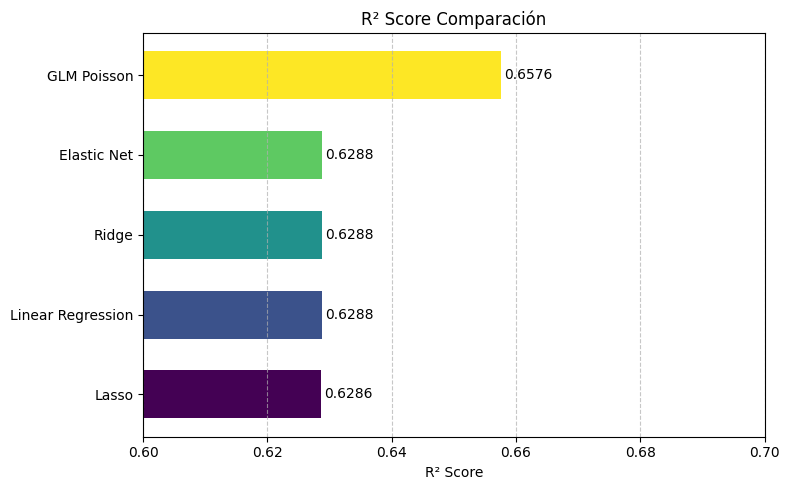

In [7]:
from pathlib import Path
file_path = Path.cwd().parent / 'entregables' / 'resultados.csv'
df = pd.read_csv(file_path)




df = df.sort_values('Adjusted_R2', ascending=True)

colors = plt.cm.viridis(np.linspace(0, 1, len(df)))

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(df['Model'], df['Adjusted_R2'], color=colors, height=0.6)

ax.set_xlim(0.6, 0.7)

for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.0005, bar.get_y() + bar.get_height()/2,
            f'{width:.4f}', va='center', ha='left', fontsize=10)

ax.set_xlabel('R² Score')
ax.set_title('R² Score Comparación')
ax.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

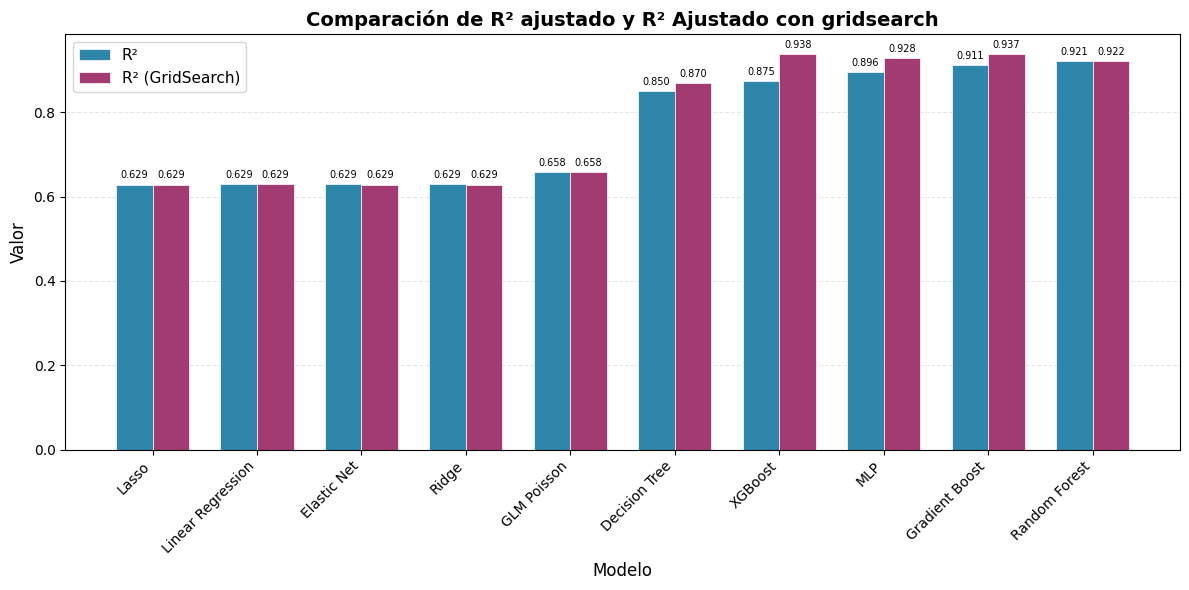

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
file_path = Path.cwd().parent / 'entregables' / 'comparacion.csv'
df = pd.read_csv(file_path)

df = df.sort_values('Adjusted_R2', ascending=True)

x = np.arange(len(df))       
width = 0.35                   

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - width/2, df['Adjusted_R2'], width, label='R²',
               color='#2E86AB', edgecolor='white', linewidth=0.5)

bars2 = ax.bar(x + width/2, df['Adjusted_R2(GridSearchCV)'], width, label='R² (GridSearch)',
               color='#A23B72', edgecolor='white', linewidth=0.5)

ax.set_xlabel('Modelo', fontsize=12)
ax.set_ylabel('Valor', fontsize=12)
ax.set_title('Comparación de R² ajustado y R² Ajustado con gridsearch', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(df['Model'], rotation=45, ha='right', fontsize=10)
ax.legend(fontsize=11)

for bar in bars1 + bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3),  # desplazamiento vertical
                textcoords="offset points",
                ha='center', va='bottom', fontsize=7)

ax.yaxis.grid(True, linestyle='--', alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()
